In [353]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix

import xgboost as xgb
import shap

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import warnings
warnings.filterwarnings("ignore")

In [354]:
df = pd.read_csv("data/UFC.csv")
df.head().style.set_sticky(axis="columns")

,event_id,event_name,date,location,fight_id,division,title_fight,method,finish_round,match_time_sec,total_rounds,referee,r_name,r_id,r_kd,r_sig_str_landed,r_sig_str_atmpted,r_sig_str_acc,r_total_str_landed,r_total_str_atmpted,r_total_str_acc,r_td_landed,r_td_atmpted,r_td_acc,r_sub_att,r_ctrl,r_head_landed,r_head_atmpted,r_head_acc,r_body_landed,r_body_atmpted,r_body_acc,r_leg_landed,r_leg_atmpted,r_leg_acc,r_dist_landed,r_dist_atmpted,r_dist_acc,r_clinch_landed,r_clinch_atmpted,r_clinch_acc,r_ground_landed,r_ground_atmpted,r_ground_acc,r_landed_head_per,r_landed_body_per,r_landed_leg_per,r_landed_dist_per,r_landed_clinch_per,r_landed_ground_per,r_nick_name_x,r_wins_x,r_losses_x,r_draws_x,r_height_x,r_weight_x,r_reach_x,r_stance_x,r_dob_x,r_splm_x,r_str_acc_x,r_sapm_x,r_str_def_x,r_td_avg_x,r_td_avg_acc_x,r_td_def_x,r_sub_avg_x,r_nick_name_y,r_wins_y,r_losses_y,r_draws_y,r_height_y,r_weight_y,r_reach_y,r_stance_y,r_dob_y,r_splm_y,r_str_acc_y,r_sapm_y,r_str_def_y,r_td_avg_y,r_td_avg_acc_y,r_td_def_y,r_sub_avg_y,r_nick_name,r_wins,r_losses,r_draws,r_height,r_weight,r_reach,r_stance,r_dob,r_splm,r_str_acc,r_sapm,r_str_def,r_td_avg,r_td_avg_acc,r_td_def,r_sub_avg,b_name,b_id,b_kd,b_sig_str_landed,b_sig_str_atmpted,b_sig_str_acc,b_total_str_landed,b_total_str_atmpted,b_total_str_acc,b_td_landed,b_td_atmpted,b_td_acc,b_sub_att,b_ctrl,b_head_landed,b_head_atmpted,b_head_acc,b_body_landed,b_body_atmpted,b_body_acc,b_leg_landed,b_leg_atmpted,b_leg_acc,b_dist_landed,b_dist_atmpted,b_dist_acc,b_clinch_landed,b_clinch_atmpted,b_clinch_acc,b_ground_landed,b_ground_atmpted,b_ground_acc,b_landed_head_per,b_landed_body_per,b_landed_leg_per,b_landed_dist_per,b_landed_clinch_per,b_landed_ground_per,b_nick_name_x,b_wins_x,b_losses_x,b_draws_x,b_height_x,b_weight_x,b_reach_x,b_stance_x,b_dob_x,b_splm_x,b_str_acc_x,b_sapm_x,b_str_def_x,b_td_avg_x,b_td_avg_acc_x,b_td_def_x,b_sub_avg_x,b_nick_name_y,b_wins_y,b_losses_y,b_draws_y,b_height_y,b_weight_y,b_reach_y,b_stance_y,b_dob_y,b_splm_y,b_str_acc_y,b_sapm_y,b_str_def_y,b_td_avg_y,b_td_avg_acc_y,b_td_def_y,b_sub_avg_y,b_nick_name,b_wins,b_losses,b_draws,b_height,b_weight,b_reach,b_stance,b_dob,b_splm,b_str_acc,b_sapm,b_str_def,b_td_avg,b_td_avg_acc,b_td_def,b_sub_avg,winner,winner_id
0,9d61d8cb1c354867,UFC Fight Night: Nurmagomedov vs. Song,2026-08-29,"Shanghai, China",ec5281a72f09d8ac,flyweight,0,Submission,1,254,3.000000,Matt Wynne,Rei Tsuruya,2f43a3e82661fa99,0.000000,39.000000,67.000000,58.000000,71.000000,101.000000,70.000000,2.000000,4.000000,50.000000,1.000000,238.000000,39.000000,67.000000,57.000000,0.000000,0.000000,nan,0.000000,0.000000,nan,0.000000,0.000000,nan,0.000000,0.000000,nan,39.000000,67.000000,57.000000,100.000000,0.000000,0.000000,0.000000,0.000000,100.000000,nan,12.000000,1.000000,0.000000,167.640000,56.700000,172.720000,Orthodox,"Jun 22, 2002",2.400000,53.000000,1.910000,43.000000,5.030000,37.000000,50.000000,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,12.000000,1.000000,0.000000,167.640000,56.700000,172.720000,Orthodox,"Jun 22, 2002",2.400000,53.000000,1.910000,43.000000,5.030000,37.000000,50.000000,2.000000,Kevin Borjas,34b96d52db1d26e6,0.000000,0.000000,0.000000,nan,1.000000,3.000000,33.000000,0.000000,0.000000,nan,0.000000,0.000000,0.000000,0.000000,nan,0.000000,0.000000,nan,0.000000,0.000000,nan,0.000000,0.000000,nan,0.000000,0.000000,nan,0.000000,0.000000,nan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,El Gallo Negro,11.000000,6.000000,0.000000,165.100000,56.700000,172.720000,Orthodox,"Dec 06, 1997",3.870000,42.000000,5.270000,50.000000,0.000000,0.000000,72.000000,0.000000,El Gallo Negro,11.000000,6.000000,0.000000,165.100000,56.700000,172.720000,Orthodox,"Dec 06, 1997",3.870000,42.000000,5.270000,50.000000,0.000000,0.000000,72.000000,0.000000,Rei Tsuruya,2f43a3e82661fa99
1,9d61d8cb1c354867,UFC Fight Night: Nurmagomedov vs. Song,2026-08-29,"Shanghai, China",a

In [355]:
cols = [
    'method',
    'date', 'r_dob_x', 'b_dob_y',
    # fighter names
    'r_name', 'b_name',
    # striking volume
    'r_splm_x', 'b_splm_y',
    # strikes absorbed
    'r_sapm_x', 'b_sapm_y',
    # striking accuracy
    'r_str_acc_x', 'b_str_acc_y',
    # striking defense
    'r_str_def_x', 'b_str_def_y',
    # takedowns landed,
    'r_td_avg_x', 'b_td_avg_y',
    # takedown accuracy
    'r_td_avg_acc_x', 'b_td_avg_acc_y',
    # takedown defense
    'r_td_def_x', 'b_td_def_y',
    # submission attempts
    'r_sub_avg_x', 'b_sub_avg_y',
    # reach
    'r_reach', 'b_reach',
    # height
    'r_height', 'b_height',
    # weight
    'r_weight_x',
    # winner name
    'winner',
    # wins and losses
    'r_wins', 'b_wins', 'r_losses', 'b_losses'
]

df = df[cols].copy()

# create column 'winner_corner' = 1 if Red won, 0 if Blue won
df['winner_corner'] = np.where(df['winner'] == df['r_name'], 1, 0)

In [356]:
# fill missing numeric values with mean
numeric_cols = [
    'r_splm_x', 'b_splm_y',
    'r_sapm_x', 'b_sapm_y',
    'r_str_acc_x', 'b_str_acc_y',
    'r_str_def_x', 'b_str_def_y',
    'r_td_avg_x', 'b_td_avg_y',
    'r_td_avg_acc_x', 'b_td_avg_acc_y',
    'r_td_def_x', 'b_td_def_y',
    'r_sub_avg_x', 'b_sub_avg_y',
    'r_reach', 'b_reach',
    'r_height', 'b_height',
    'r_weight_x',
    'r_wins', 'b_wins', 'r_losses', 'b_losses'
]

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by="date").reset_index(drop=True)

# --- define a cutoff for the whole pipeline, used everywhere downstream ---
CUTOFF_DATE = df["date"].quantile(0.8)  

train_mask = df["date"] < CUTOFF_DATE

# fill missing numeric values using training-period stats
col_means = df.loc[train_mask, numeric_cols].mean()
df[numeric_cols] = df[numeric_cols].fillna(col_means)

In [357]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by="date")
df["r_dob_x"] = pd.to_datetime(
    df["r_dob_x"],
    errors="coerce",
    format="mixed"
)

df["b_dob_y"] = pd.to_datetime(
    df["b_dob_y"],
    errors="coerce",
    format="mixed"
)

In [358]:
df.head()

,method,date,r_dob_x,b_dob_y,r_name,b_name,r_splm_x,b_splm_y,r_sapm_x,b_sapm_y,...,b_reach,r_height,b_height,r_weight_x,winner,r_wins,b_wins,r_losses,b_losses,winner_corner
0,Submission,1994-03-11,NaT,NaT,Frank Hamaker,Thaddeus Luster,0.00,0.0,0.00,0.0,...,182.941931,178.754367,190.500000,77.008886,Frank Hamaker,1.0,0.0,0.0,1.0,1
14,Submission,1994-03-11,1963-08-28,NaT,Patrick Smith,Ray Wizard,0.00,0.0,0.00,0.0,...,182.941931,187.960000,178.667522,102.060000,Patrick Smith,20.0,0.0,17.0,1.0,1
13,Submission,1994-03-11,NaT,1975-12-04,Scott Morris,Sean Daugherty,0.00,0.0,0.00,0.0,...,182.941931,177.800000,182.880000,95.250000,Scott Morris,2.0,0.0,1.0,2.0,1
12,Submission,1994-03-11,1966-12-12,1968-06-30,Royce Gracie,Minoki Ichihara,0.88,0.0,1.13,0.0,...,182.941931,185.420000,170.180000,79.380000,Royce Gracie,15.0,0.0,2.0,1.0,1
11,Submission,1994-03-11,1966-12-12,1969-07-24,Royce Gracie,Jason DeLucia,0.88,0.0,1.13,0.0,...,182.941931,185.420000,180.340000,79.380000,Royce Gracie,15.0,33.0,2.0,21.0,1


In [359]:
# Age at fight
df["r_age"] = (
    (df["date"] - df["r_dob_x"]).dt.days / 365.25
)

df["b_age"] = (
    (df["date"] - df["b_dob_y"]).dt.days / 365.25
)    

In [360]:
df = df.sort_values(by='date')

<h1>Momentum Features</h1>

In [361]:
# red fighter history
red_df = pd.DataFrame({
    "fighter": df["r_name"],
    "date": df["date"],
    "method": df["method"],
    "win": np.where(df["winner"] == df["r_name"], 1, 0)
})

# blue fighter history
blue_df = pd.DataFrame({
    "fighter": df["b_name"],
    "date": df["date"],
    "method": df["method"],
    "win": np.where(df["winner"] == df["b_name"], 1, 0)
})

# combine together
fighter_history = pd.concat([red_df, blue_df], ignore_index=True)

# sort chronologically
fighter_history = fighter_history.sort_values(by="date")


fighter_history["ko_win"] = np.where(
    (fighter_history["win"] == 1) &
    (fighter_history["method"].str.contains("KO", case=False, na=False)),
    1,
    0
)

fighter_history["ko_loss"] = np.where(
    (fighter_history["win"] == 0) &
    (fighter_history["method"].str.contains("KO", case=False, na=False)),
    1,
    0
)

fighter_history["sub_win"] = np.where(
    (fighter_history["win"] == 1) &
    (fighter_history["method"].str.contains("Sub", case=False, na=False)),
    1,
    0
)

fighter_history["sub_loss"] = np.where(
    (fighter_history["win"] == 0) &
    (fighter_history["method"].str.contains("Sub", case=False, na=False)),
    1,
    0
)

fighter_history["dec_win"] = np.where(
    (fighter_history["win"] == 1) &
    (fighter_history["method"].str.contains("Decision", case=False, na=False)),
    1,
    0
)

fighter_history["dec_loss"] = np.where(
    (fighter_history["win"] == 0) &
    (fighter_history["method"].str.contains("Decision", case=False, na=False)),
    1,
    0
)

career_cols = [
    "ko_win",
    "ko_loss",
    "sub_win",
    "sub_loss",
    "dec_win",
    "dec_loss"
]

for col in career_cols:
    fighter_history[f"total_{col}"] = (
        fighter_history
        .groupby("fighter")[col]
        .transform(lambda x: x.cumsum().shift(1))
    )

total_cols = [f"total_{col}" for col in career_cols]
fighter_history[total_cols] = fighter_history[total_cols].fillna(0)

In [362]:
fighter_history["last_3_wins"] = (
    fighter_history
    .groupby("fighter")["win"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum())
)

fighter_history["last_6_wins"] = (
    fighter_history
    .groupby("fighter")["win"]
    .transform(lambda x: x.shift(1).rolling(6, min_periods=1).sum())
)

fighter_history["last_3_wins"] = fighter_history["last_3_wins"].fillna(0)
fighter_history["last_6_wins"] = fighter_history["last_6_wins"].fillna(0)

<h1>Activity/ Experience</h1>

In [363]:
# Total UFC experience
fighter_history["ufc_fights_before"] = (
    fighter_history
    .groupby("fighter")
    .cumcount()
)

# Recent Activity
fighter_history["date"] = pd.to_datetime(fighter_history["date"])
fighter_history["days_since_last_fight"] = (
    fighter_history
    .groupby("fighter")["date"]
    .diff()
    .dt.days
)

fighter_history["days_since_last_fight"] = (
    fighter_history["days_since_last_fight"].fillna(365)
)

<h1>Elo System</h1>

In [364]:
fighter_elo = {}
K = 32  # how fast ratings change

import math

def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

df = df.sort_values("date").reset_index(drop=True)

# split before Elo so test fights don't influence training ratings
cutoff_raw = (df["date"] < CUTOFF_DATE).sum()
train_df = df.iloc[:cutoff_raw].copy()
test_df  = df.iloc[cutoff_raw:].copy()

r_elo = []
b_elo = []

for _, row in train_df.iterrows():

    r = row["r_name"]
    b = row["b_name"]

    # default rating
    r_rating = fighter_elo.get(r, 1500)
    b_rating = fighter_elo.get(b, 1500)

    # store current ratings as features
    r_elo.append(r_rating)
    b_elo.append(b_rating)

    # expected scores
    r_exp = expected_score(r_rating, b_rating)
    b_exp = 1 - r_exp

    # actual outcome
    r_score = 1 if row["winner_corner"] == 1 else 0
    b_score = 1 - r_score

    # update ratings
    fighter_elo[r] = r_rating + K * (r_score - r_exp)
    fighter_elo[b] = b_rating + K * (b_score - b_exp)

train_df["r_elo"] = r_elo
train_df["b_elo"] = b_elo

# test fighters get their frozen Elo from end of training
test_df["r_elo"] = [fighter_elo.get(r, 1500) for r in test_df["r_name"]]
test_df["b_elo"] = [fighter_elo.get(b, 1500) for b in test_df["b_name"]]

df = pd.concat([train_df, test_df]).sort_values("date").reset_index(drop=True)
df["elo_diff"] = df["r_elo"] - df["b_elo"]

In [365]:
# weighted wins

elo_lookup_r = df[["date", "r_name", "r_elo"]].rename(columns={
    "r_name": "fighter",
    "r_elo": "opp_elo"
})

elo_lookup_b = df[["date", "b_name", "b_elo"]].rename(columns={
    "b_name": "fighter",
    "b_elo": "opp_elo"
})

elo_lookup = pd.concat([elo_lookup_r, elo_lookup_b])

fighter_history = fighter_history.merge(
    elo_lookup,
    on=["fighter", "date"],
    how="left"
)

fighter_history["weighted_win"] = fighter_history["win"] * fighter_history["opp_elo"]
fighter_history["weighted_loss"] = (1 - fighter_history["win"]) * fighter_history["opp_elo"]

fighter_history["quality_last_3"] = (
    fighter_history
    .groupby("fighter")["weighted_win"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum())
)

fighter_history["quality_last_6"] = (
    fighter_history
    .groupby("fighter")["weighted_win"]
    .transform(lambda x: x.shift(1).rolling(6, min_periods=1).sum())
)

In [366]:
# ============================================================
# CHIN METRIC + ELO-WEIGHTED FINISH QUALITY
# ============================================================

# Elo-weighted finish events — a KO win over a high-Elo opponent counts
# for more than a KO win over a low-Elo opponent.
fighter_history["weighted_ko_win"]  = fighter_history["ko_win"]  * fighter_history["opp_elo"]
fighter_history["weighted_sub_win"] = fighter_history["sub_win"] * fighter_history["opp_elo"]
fighter_history["weighted_ko_loss"] = fighter_history["ko_loss"] * fighter_history["opp_elo"]
fighter_history["weighted_sub_loss"]= fighter_history["sub_loss"]* fighter_history["opp_elo"]

finish_quality_cols = ["weighted_ko_win", "weighted_sub_win", "weighted_ko_loss", "weighted_sub_loss"]

# cumulative + shifted, so THIS fight's own outcome never leaks into its own features
for col in finish_quality_cols:
    fighter_history[f"total_{col}"] = (
        fighter_history.groupby("fighter")[col].transform(lambda x: x.cumsum().shift(1))
    )

total_finish_quality_cols = [f"total_{c}" for c in finish_quality_cols]
fighter_history[total_finish_quality_cols] = fighter_history[total_finish_quality_cols].fillna(0)

# Chin metric: share of career fights lost by KO/TKO, evaluated BEFORE this fight.
# total_ko_loss and ufc_fights_before are both already lagged (cumsum().shift(1)
# and cumcount respectively) — dividing them is leakage-safe.
fighter_history["chin_metric"] = (
    fighter_history["total_ko_loss"] / fighter_history["ufc_fights_before"].replace(0, np.nan)
)
# NaN here = fighter's first-ever fight (no history to compute a chin rate from).
# Left as NaN intentionally — filled with a TRAIN-ONLY mean later, not 0.

# ============================================================
# FINISH RATE + DECISION RELIANCE
# ============================================================
# Both use totals already computed above (total_ko_win, total_sub_win,
# total_dec_win, total_dec_loss are all cumsum().shift(1) — leakage-safe)
# divided by ufc_fights_before (also already lagged via cumcount()).

fighter_history["finish_rate"] = (
    (fighter_history["total_ko_win"] + fighter_history["total_sub_win"])
    / fighter_history["ufc_fights_before"].replace(0, np.nan)
)

fighter_history["decision_rate"] = (
    (fighter_history["total_dec_win"] + fighter_history["total_dec_loss"])
    / fighter_history["ufc_fights_before"].replace(0, np.nan)
)
# NaN on a fighter's first fight (no history yet) — same treatment as
# chin_metric: left as NaN here, filled with a TRAIN-ONLY mean later,
# never 0 (0 would falsely say "never finishes / never goes to decision").

<h1>Merge</h1>

In [367]:
# NAME + DATE ALIGN
df["r_name"] = df["r_name"].str.strip().str.lower()
df["b_name"] = df["b_name"].str.strip().str.lower()
fighter_history["fighter"] = fighter_history["fighter"].str.strip().str.lower()

df["date"] = pd.to_datetime(df["date"])
fighter_history["date"] = pd.to_datetime(fighter_history["date"])

# sort data for time-based merging
df = df.sort_values("date")
fighter_history = fighter_history.sort_values("date")


# RED FEATURES
red_features = fighter_history.copy()

red_features = red_features.rename(columns={
    "fighter": "r_name",
    "last_3_wins": "r_last_3_wins",
    "last_6_wins": "r_last_6_wins",

    "total_ko_win": "r_total_ko_win",
    "total_ko_loss": "r_total_ko_loss",
    "total_sub_win": "r_total_sub_win",
    "total_sub_loss": "r_total_sub_loss",
    "total_dec_win": "r_total_dec_win",
    "total_dec_loss": "r_total_dec_loss",

    "ufc_fights_before": "r_ufc_fights_before",
    "days_since_last_fight": "r_days_since_last_fight",

    "quality_last_3": "r_quality_last_3",
    "quality_last_6": "r_quality_last_6",

    "chin_metric": "r_chin_metric",
    "total_weighted_ko_win": "r_total_weighted_ko_win",
    "total_weighted_sub_win": "r_total_weighted_sub_win",
    "total_weighted_ko_loss": "r_total_weighted_ko_loss",
    "total_weighted_sub_loss": "r_total_weighted_sub_loss",
    "finish_rate": "r_finish_rate",      
    "decision_rate": "r_decision_rate",  
})


# BLUE FEATURES
blue_features = fighter_history.copy()

blue_features = blue_features.rename(columns={
    "fighter": "b_name",
    "last_3_wins": "b_last_3_wins",
    "last_6_wins": "b_last_6_wins",

    "total_ko_win": "b_total_ko_win",
    "total_ko_loss": "b_total_ko_loss",
    "total_sub_win": "b_total_sub_win",
    "total_sub_loss": "b_total_sub_loss",
    "total_dec_win": "b_total_dec_win",
    "total_dec_loss": "b_total_dec_loss",

    "ufc_fights_before": "b_ufc_fights_before",
    "days_since_last_fight": "b_days_since_last_fight",

    "quality_last_3": "b_quality_last_3",
    "quality_last_6": "b_quality_last_6",

    "chin_metric": "b_chin_metric",
    "total_weighted_ko_win": "b_total_weighted_ko_win",
    "total_weighted_sub_win": "b_total_weighted_sub_win",
    "total_weighted_ko_loss": "b_total_weighted_ko_loss",
    "total_weighted_sub_loss": "b_total_weighted_sub_loss",
    "finish_rate": "b_finish_rate",
    "decision_rate": "b_decision_rate",
})

df = df.drop_duplicates(["r_name", "b_name", "date"])
fighter_history = fighter_history.drop_duplicates(["fighter", "date"])

# merge red fighter historical stats (only past data)
df = pd.merge_asof(
    df.sort_values("date"),
    red_features.sort_values("date"),
    by="r_name",
    on="date",
    direction="backward"
)


# merge blue fighter historical stats (only past data)
df = pd.merge_asof(
    df.sort_values("date"),
    blue_features.sort_values("date"),
    by="b_name",
    on="date",
    direction="backward"
)


# columns to clean missing values
new_cols = [

    # RED
    "r_last_3_wins",
    "r_last_6_wins",
    "r_total_ko_win",
    "r_total_ko_loss",
    "r_total_sub_win",
    "r_total_sub_loss",
    "r_total_dec_win",
    "r_total_dec_loss",
    "r_ufc_fights_before",
    "r_days_since_last_fight",
    "r_quality_last_3",
    "r_quality_last_6",
    "r_total_weighted_ko_win", "r_total_weighted_sub_win", "r_total_weighted_ko_loss", "r_total_weighted_sub_loss",

    # BLUE
    "b_last_3_wins",
    "b_last_6_wins",
    "b_total_ko_win",
    "b_total_ko_loss",
    "b_total_sub_win",
    "b_total_sub_loss",
    "b_total_dec_win",
    "b_total_dec_loss",
    "b_ufc_fights_before",
    "b_days_since_last_fight",
    "b_quality_last_3",
    "b_quality_last_6",
    "b_total_weighted_ko_win", "b_total_weighted_sub_win", "b_total_weighted_ko_loss", "b_total_weighted_sub_loss",

]

# fill missing values with 0
df[new_cols] = df[new_cols].fillna(0)

# fill missing elo

fighter_history["opp_elo"] = fighter_history["opp_elo"].fillna(1500)

# ------------------------------------------------------------
# Fill chin_metric / finish_rate / decision_rate — these were
# deliberately NOT included in new_cols above, since 0 would be
# the wrong value for a debut fighter (0 chin rate implies "never
# been knocked out," which isn't true, it's "unknown"). 
# ------------------------------------------------------------

rate_fill_pairs = [
    ("r_chin_metric", "b_chin_metric"),
    ("r_finish_rate", "b_finish_rate"),
    ("r_decision_rate", "b_decision_rate"),
]

rate_train_mask = df["date"] < CUTOFF_DATE

for col_r, col_b in rate_fill_pairs:
    train_mean = pd.concat([
        df.loc[rate_train_mask, col_r],
        df.loc[rate_train_mask, col_b]
    ]).mean()

    df[col_r] = df[col_r].fillna(train_mean)
    df[col_b] = df[col_b].fillna(train_mean)

In [368]:
df.sort_values(by='date', ascending=False).head().style.set_sticky(axis="columns")

,method_x,date,r_dob_x,b_dob_y,r_name,b_name,r_splm_x,b_splm_y,r_sapm_x,b_sapm_y,r_str_acc_x,b_str_acc_y,r_str_def_x,b_str_def_y,r_td_avg_x,b_td_avg_y,r_td_avg_acc_x,b_td_avg_acc_y,r_td_def_x,b_td_def_y,r_sub_avg_x,b_sub_avg_y,r_reach,b_reach,r_height,b_height,r_weight_x,winner,r_wins,b_wins,r_losses,b_losses,winner_corner,r_age,b_age,r_elo,b_elo,elo_diff,method_y,win_x,ko_win_x,ko_loss_x,sub_win_x,sub_loss_x,dec_win_x,dec_loss_x,r_total_ko_win,r_total_ko_loss,r_total_sub_win,r_total_sub_loss,r_total_dec_win,r_total_dec_loss,r_last_3_wins,r_last_6_wins,r_ufc_fights_before,r_days_since_last_fight,opp_elo_x,weighted_win_x,weighted_loss_x,r_quality_last_3,r_quality_last_6,weighted_ko_win_x,weighted_sub_win_x,weighted_ko_loss_x,weighted_sub_loss_x,r_total_weighted_ko_win,r_total_weighted_sub_win,r_total_weighted_ko_loss,r_total_weighted_sub_loss,r_chin_metric,r_finish_rate,r_decision_rate,method,win_y,ko_win_y,ko_loss_y,sub_win_y,sub_loss_y,dec_win_y,dec_loss_y,b_total_ko_win,b_total_ko_loss,b_total_sub_win,b_total_sub_loss,b_total_dec_win,b_total_dec_loss,b_last_3_wins,b_last_6_wins,b_ufc_fights_before,b_days_since_last_fight,opp_elo_y,weighted_win_y,weighted_loss_y,b_quality_last_3,b_quality_last_6,weighted_ko_win_y,weighted_sub_win_y,weighted_ko_loss_y,weighted_sub_loss_y,b_total_weighted_ko_win,b_total_weighted_sub_win,b_total_weighted_ko_loss,b_total_weighted_sub_loss,b_chin_metric,b_finish_rate,b_decision_rate
8818,Submission,2026-08-29 00:00:00,2002-06-22 00:00:00,1997-12-06 00:00:00,rei tsuruya,kevin borjas,2.400000,3.870000,1.910000,5.270000,53.000000,42.000000,43.000000,50.000000,5.030000,0.000000,37.000000,0.000000,50.000000,72.000000,2.000000,0.000000,172.720000,172.720000,167.640000,165.100000,56.700000,Rei Tsuruya,12.000000,11.000000,1.000000,6.000000,1,24.186174,28.728268,1500.000000,1500.000000,0.000000,Submission,1,0,0,1,0,0,0,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,2.000000,2.000000,3,91.000000,1500.000000,1500.000000,0.000000,3000.000000,3000.000000,0.000000,1500.000000,0.000000,0.000000,0.000000,1500.000000,0.000000,0.000000,0.000000,0.333333,0.666667,Submission,0,0,0,0,1,0,0,0.000000,2.000000,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,6,70.000000,1500.000000,0.000000,1500.000000,1500.000000,3000.000000,0.000000,0.000000,0.000000,1500.000000,0.000000,0.000000,3000.000000,0.000000,0.333333,0.000000,0.666667
8817,Decision - Unanimous,2026-08-29 00:00:00,1992-03-21 00:00:00,1996-01-20 00:00:00,alex perez,sumudaerji,4.220000,4.400000,3.240000,2.290000,45.000000,50.000000,58.000000,63.000000,2.070000,0.760000,45.000000,37.000000,74.000000,73.000000,0.800000,0.500000,165.100000,182.880000,167.640000,172.720000,56.700000,Sumudaerji,26.000000,20.000000,11.000000,7.000000,0,34.439425,30.606434,1547.269429,1511.916168,35.353261,Decision - Unanimous,0,0,0,0,0,0,1,4.000000,2.000000,2.000000,3.000000,2.000000,1.000000,1.000000,2.000000,15,91.000000,1547.269429,0.000000,1547.269429,1547.269429,3094.538858,0.000000,0.000000,0.000000,0.000000,6185.901502,3047.629846,3092.551403,4687.280511,0.133333,0.400000,0.200000,Decision - Unanimous,1,0,0,0,0,1,0,1.000000,0.000000,0.000000,3.000000,5.000000,1.000000,2.000000,3.000000,11,91.000000,1511.916168,1511.916168,0.000000,3023.832337,4535.748505,0.000000,0.000000,0.000000,0.000000,1499.295993,0.000000,0.000000,4541.043915,0.000000,0.090909,0.545455
8816,Submission,2026-08-29 00:00:00,2000-12-29 00:00:00,1999-02-04 00:00:00,namsrai batbayar,andre lima,4.440000,3.940000,3.420000,2.660000,45.000000,56.000000,48.000000,58.000000,2.850000,1.110000,30.000000,60.000000,100.000000,75.000000,0.900000,0.900000,172.720000,170.180000,162.560000,170.180000,56.700000,Andre Lima,10.000000,12.000000,2.000000,1.000000,0,25.664613,27.564682,1500.000000,1500.000000,0.000000,Submission,0,0,0,0,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,365.000000,1500.000000,0.000000,1500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1500.000000,0.0000

In [369]:

# RATE-BASED FEATURES 

# win rate (core improvement over raw wins/losses)
df["r_fight_total"] = (df["r_wins"] + df["r_losses"]).replace(0, np.nan)
df["b_fight_total"] = (df["b_wins"] + df["b_losses"]).replace(0, np.nan)

df["r_win_rate"] = df["r_wins"] / df["r_fight_total"]
df["b_win_rate"] = df["b_wins"] / df["b_fight_total"]

df["r_win_rate"] = df["r_win_rate"].fillna(0)
df["b_win_rate"] = df["b_win_rate"].fillna(0)


# MOMENTUM → RATE FEATURES

df["r_total_fights"] = df["r_ufc_fights_before"].replace(0, np.nan)
df["b_total_fights"] = df["b_ufc_fights_before"].replace(0, np.nan)

# win momentum rate (better than raw rolling sums)
df["r_momentum_3_rate"] = df["r_last_3_wins"] / 3
df["b_momentum_3_rate"] = df["b_last_3_wins"] / 3

df["r_momentum_6_rate"] = df["r_last_6_wins"] / 6
df["b_momentum_6_rate"] = df["b_last_6_wins"] / 6

# QUALITY FEATURES → NORMALIZED

df["r_quality_3_rate"] = df["r_quality_last_3"] / 3
df["b_quality_3_rate"] = df["b_quality_last_3"] / 3

df["r_quality_6_rate"] = df["r_quality_last_6"] / 6
df["b_quality_6_rate"] = df["b_quality_last_6"] / 6

# CORE DIFFERENCE FEATURES (WHAT MODEL SHOULD ACTUALLY USE)

df["win_rate_diff"] = df["r_win_rate"] - df["b_win_rate"]

df["momentum_3_diff"] = df["r_momentum_3_rate"] - df["b_momentum_3_rate"]
df["momentum_6_diff"] = df["r_momentum_6_rate"] - df["b_momentum_6_rate"]

df["quality_3_diff"] = df["r_quality_3_rate"] - df["b_quality_3_rate"]
df["quality_6_diff"] = df["r_quality_6_rate"] - df["b_quality_6_rate"]

df["experience_diff"] = df["r_ufc_fights_before"] - df["b_ufc_fights_before"]

<h1>Fix Corner Bias</h1>

In [370]:
# =========================
# CORNER FLIP 
# =========================

df_base = df.copy().sort_values("date").reset_index(drop=True)
df_flip = df.copy().sort_values("date").reset_index(drop=True)

# -------------------------
# 1. swap identity columns
# -------------------------
df_flip[["r_name", "b_name"]] = df_flip[["b_name", "r_name"]].values
df_flip[["r_age", "b_age"]] = df_flip[["b_age", "r_age"]].values
df_flip[["r_reach", "b_reach"]] = df_flip[["b_reach", "r_reach"]].values
df_flip[["r_height", "b_height"]] = df_flip[["b_height", "r_height"]].values

# -------------------------
# 2. swap Elo
# -------------------------
df_flip[["r_elo", "b_elo"]] = df_flip[["b_elo", "r_elo"]].values

# -------------------------
# 3. swap directional features
# -------------------------

swap_map = {
    "striking_volume":  ("r_splm_x",          "b_splm_y"),
    "striking_absorbed":("r_sapm_x",           "b_sapm_y"),
    "striking_acc":     ("r_str_acc_x",        "b_str_acc_y"),
    "striking_def":     ("r_str_def_x",        "b_str_def_y"),
    "td_avg":           ("r_td_avg_x",         "b_td_avg_y"),
    "td_acc":           ("r_td_avg_acc_x",     "b_td_avg_acc_y"),
    "td_def":           ("r_td_def_x",         "b_td_def_y"),
    "sub_avg":          ("r_sub_avg_x",        "b_sub_avg_y"),
    "wins":             ("r_wins",             "b_wins"),
    "losses":           ("r_losses",           "b_losses"),
    "win_rate":         ("r_win_rate",         "b_win_rate"),
    "last_3_wins":      ("r_last_3_wins",      "b_last_3_wins"),
    "last_6_wins":      ("r_last_6_wins",      "b_last_6_wins"),
    "ko_win":           ("r_total_ko_win",     "b_total_ko_win"),
    "ko_loss":          ("r_total_ko_loss",    "b_total_ko_loss"),
    "sub_win":          ("r_total_sub_win",    "b_total_sub_win"),
    "sub_loss":         ("r_total_sub_loss",   "b_total_sub_loss"),
    "dec_win":          ("r_total_dec_win",    "b_total_dec_win"),
    "dec_loss":         ("r_total_dec_loss",   "b_total_dec_loss"),
    "ufc_fights":       ("r_ufc_fights_before","b_ufc_fights_before"),
    "days_since":       ("r_days_since_last_fight", "b_days_since_last_fight"),
    "quality_3":        ("r_quality_last_3",   "b_quality_last_3"),
    "quality_6":        ("r_quality_last_6",   "b_quality_last_6"),
    "chin_metric":     ("r_chin_metric", "b_chin_metric"),
    "weighted_ko_win": ("r_total_weighted_ko_win", "b_total_weighted_ko_win"),
    "weighted_sub_win":("r_total_weighted_sub_win", "b_total_weighted_sub_win"),
    "weighted_ko_loss":("r_total_weighted_ko_loss", "b_total_weighted_ko_loss"),
    "weighted_sub_loss":("r_total_weighted_sub_loss", "b_total_weighted_sub_loss"),
    "finish_rate":   ("r_finish_rate", "b_finish_rate"),
    "decision_rate": ("r_decision_rate", "b_decision_rate"),
}

for _, (r_col, b_col) in swap_map.items():
    df_flip[[r_col, b_col]] = df_flip[[b_col, r_col]].values

# -------------------------
# 4. flip label
# -------------------------
df_flip["winner_corner"] = 1 - df_flip["winner_corner"]

# -------------------------
# 5. split THEN combine — flip only training data
# -------------------------
cutoff_raw = (df["date"] < CUTOFF_DATE).sum()
train_base = df_base.iloc[:cutoff_raw]
test_clean = df_base.iloc[cutoff_raw:]

train_flip = df_flip.iloc[:cutoff_raw]

train_balanced = pd.concat([train_base, train_flip], ignore_index=True)

df_balanced = pd.concat([train_balanced, test_clean], ignore_index=True)

# -------------------------
# 6. re-sort after concat
# -------------------------
df_balanced = df_balanced.sort_values("date").reset_index(drop=True)

<h1>Final Model Feature Input</h1>

In [371]:
PRIME_AGE = 32  # rough MMA athletic prime

# final model input
df_model = df_balanced.copy()

# physical diffs
df_model["age_diff"] = df_model["r_age"] - df_model["b_age"]
df_model["reach_diff"] = df_model["r_reach"] - df_model["b_reach"]
df_model["height_diff"] = df_model["r_height"] - df_model["b_height"]
df_model["weight_class"] = df_model["r_weight_x"]
df_model["r_age_from_prime"] = (df_model["r_age"] - PRIME_AGE).abs()
df_model["b_age_from_prime"] = (df_model["b_age"] - PRIME_AGE).abs()
df_model["age_from_prime_diff"] = df_model["r_age_from_prime"] - df_model["b_age_from_prime"]
df_model["age_diff_sq"] = df_model["age_diff"] ** 2

# striking diffs
df_model["str_volume_diff"] = df_model["r_splm_x"] - df_model["b_splm_y"]
df_model["str_acc_diff"] = df_model["r_str_acc_x"] - df_model["b_str_acc_y"]
df_model["str_def_diff"] = df_model["r_str_def_x"] - df_model["b_str_def_y"]
df_model["sapm_diff"] = df_model["r_sapm_x"] - df_model["b_sapm_y"]

# grappling diffs
df_model["td_volume_diff"] = df_model["r_td_avg_x"] - df_model["b_td_avg_y"]
df_model["td_acc_diff"] = df_model["r_td_avg_acc_x"] - df_model["b_td_avg_acc_y"]
df_model["td_def_diff"] = df_model["r_td_def_x"] - df_model["b_td_def_y"]
df_model["sub_diff"] = df_model["r_sub_avg_x"] - df_model["b_sub_avg_y"]

# win rate
df_model["r_win_rate"] = df_model["r_wins"] / (df_model["r_wins"] + df_model["r_losses"] + 1e-6)
df_model["b_win_rate"] = df_model["b_wins"] / (df_model["b_wins"] + df_model["b_losses"] + 1e-6)
df_model["win_rate_diff"] = df_model["r_win_rate"] - df_model["b_win_rate"]

df_model["finish_rate_diff"] = df_model["r_finish_rate"] - df_model["b_finish_rate"]
df_model["decision_rate_diff"] = df_model["r_decision_rate"] - df_model["b_decision_rate"]

# experience
df_model["fights_diff"] = df_model["r_ufc_fights_before"] - df_model["b_ufc_fights_before"]
df_model["rest_diff"] = df_model["r_days_since_last_fight"] - df_model["b_days_since_last_fight"]

# momentum
df_model["r_momentum_3"] = df_model["r_last_3_wins"] / 3
df_model["b_momentum_3"] = df_model["b_last_3_wins"] / 3
df_model["r_momentum_6"] = df_model["r_last_6_wins"] / 6
df_model["b_momentum_6"] = df_model["b_last_6_wins"] / 6

df_model["momentum_3_diff"] = df_model["r_momentum_3"] - df_model["b_momentum_3"]
df_model["momentum_6_diff"] = df_model["r_momentum_6"] - df_model["b_momentum_6"]

# quality
df_model["r_quality_3"] = df_model["r_quality_last_3"] / 3
df_model["b_quality_3"] = df_model["b_quality_last_3"] / 3
df_model["r_quality_6"] = df_model["r_quality_last_6"] / 6
df_model["b_quality_6"] = df_model["b_quality_last_6"] / 6

df_model["quality_3_diff"] = df_model["r_quality_3"] - df_model["b_quality_3"]
df_model["quality_6_diff"] = df_model["r_quality_6"] - df_model["b_quality_6"]

# elo
df_model["elo_diff"] = df_model["r_elo"] - df_model["b_elo"]
df_model["total_elo"] = df_model["r_elo"] + df_model["b_elo"]

# ============================================================
# OFFENSE / DEFENSE COMPOSITE SCORES (Elo-aware)
# ============================================================
# Z-scored so stats on very different scales (splm ~0-10, str_acc ~0-100,
# chin_metric ~0-1) combine meaningfully. Stats fit on the TRAINING PERIOD
# ONLY (same CUTOFF_DATE used throughout this notebook) to stay leakage-safe.

score_train_mask = df_model["date"] < CUTOFF_DATE

def train_zscore(data, col, mask):
    mean = data.loc[mask, col].mean()
    std = data.loc[mask, col].std()
    std = std if std > 0 else 1.0
    return (data[col] - mean) / std

corner_cols = {
    "r": {
        "splm": "r_splm_x", "str_acc": "r_str_acc_x", "str_def": "r_str_def_x", "sapm": "r_sapm_x",
        "td_avg": "r_td_avg_x", "td_acc": "r_td_avg_acc_x", "td_def": "r_td_def_x", "sub_avg": "r_sub_avg_x",
        "ko_win_q": "r_total_weighted_ko_win", "sub_win_q": "r_total_weighted_sub_win",
        "ko_loss_q": "r_total_weighted_ko_loss", "sub_loss_q": "r_total_weighted_sub_loss",
        "chin": "r_chin_metric",
    },
    "b": {
        "splm": "b_splm_y", "str_acc": "b_str_acc_y", "str_def": "b_str_def_y", "sapm": "b_sapm_y",
        "td_avg": "b_td_avg_y", "td_acc": "b_td_avg_acc_y", "td_def": "b_td_def_y", "sub_avg": "b_sub_avg_y",
        "ko_win_q": "b_total_weighted_ko_win", "sub_win_q": "b_total_weighted_sub_win",
        "ko_loss_q": "b_total_weighted_ko_loss", "sub_loss_q": "b_total_weighted_sub_loss",
        "chin": "b_chin_metric",
    },
}

for corner, cmap in corner_cols.items():
    z = {key: train_zscore(df_model, col, score_train_mask) for key, col in cmap.items()}

    df_model[f"{corner}_striking_offense"] = z["splm"] + z["str_acc"] + z["ko_win_q"]
    df_model[f"{corner}_striking_defense"] = z["str_def"] - z["sapm"] - z["chin"] - z["ko_loss_q"]
    df_model[f"{corner}_grappling_offense"] = z["td_avg"] + z["td_acc"] + z["sub_avg"] + z["sub_win_q"]
    df_model[f"{corner}_grappling_defense"] = z["td_def"] - z["sub_loss_q"]

# ---- diffs ----
df_model["chin_diff"] = df_model["r_chin_metric"] - df_model["b_chin_metric"]
df_model["striking_offense_diff"] = df_model["r_striking_offense"] - df_model["b_striking_offense"]
df_model["striking_defense_diff"] = df_model["r_striking_defense"] - df_model["b_striking_defense"]
df_model["grappling_offense_diff"] = df_model["r_grappling_offense"] - df_model["b_grappling_offense"]
df_model["grappling_defense_diff"] = df_model["r_grappling_defense"] - df_model["b_grappling_defense"]

# ---- matchup interactions: red's offense vs blue's defense, and vice versa ----
df_model["r_striking_edge"] = df_model["r_striking_offense"] - df_model["b_striking_defense"]
df_model["b_striking_edge"] = df_model["b_striking_offense"] - df_model["r_striking_defense"]
df_model["striking_edge_diff"] = df_model["r_striking_edge"] - df_model["b_striking_edge"]

df_model["r_grappling_edge"] = df_model["r_grappling_offense"] - df_model["b_grappling_defense"]
df_model["b_grappling_edge"] = df_model["b_grappling_offense"] - df_model["r_grappling_defense"]
df_model["grappling_edge_diff"] = df_model["r_grappling_edge"] - df_model["b_grappling_edge"]

# multiplicative interaction — "both high-offense = firefight" style signal, distinct from a difference
df_model["striking_offense_interaction"] = df_model["r_striking_offense"] * df_model["b_striking_offense"]
df_model["grappling_offense_interaction"] = df_model["r_grappling_offense"] * df_model["b_grappling_offense"]

# drop raw features
df_model = df_model[[col for col in df_model.columns if not col.startswith("r_") and not col.startswith("b_")]]


# Add weight class for future use if wanted
def weight_to_division(w):
    bounds = [
        (56.7, "flyweight"), (61.2, "bantamweight"), (65.8, "featherweight"),
        (70.3, "lightweight"), (77.1, "welterweight"), (83.9, "middleweight"),
        (93.0, "light_heavyweight"), (120.2, "heavyweight")
    ]
    for limit, name in bounds:
        if w <= limit + 1:
            return name
    return "heavyweight"

df_model["division"] = df_model["weight_class"].apply(weight_to_division)
division_dummies = pd.get_dummies(df_model["division"], prefix="div")
df_model = pd.concat([df_model, division_dummies], axis=1)

df_model.head()

,method_x,date,winner,winner_corner,elo_diff,method_y,win_x,ko_win_x,ko_loss_x,sub_win_x,...,grappling_offense_interaction,division,div_bantamweight,div_featherweight,div_flyweight,div_heavyweight,div_light_heavyweight,div_lightweight,div_middleweight,div_welterweight
0,Submission,1994-03-11,Frank Hamaker,1,0.000000,Submission,1,0,0,1,...,19.695165,welterweight,False,False,False,False,False,False,False,True
1,Submission,1994-03-11,Royce Gracie,0,-15.263693,KO/TKO,1,1,0,0,...,-11.605804,middleweight,False,False,False,False,False,False,True,False
2,KO/TKO,1994-03-11,Remco Pardoel,0,15.297533,KO/TKO,1,1,0,0,...,10.706403,heavyweight,False,False,False,True,False,False,False,False
3,KO/TKO,1994-03-11,Orlando Wiet,0,0.000000,KO/TKO,1,1,0,0,...,19.695165,welterweight,False,False,False,False,False,False,False,True
4,KO/TKO,1994-03-11,Patrick Smith,0,-1.340348,Submission,1,0,0,1,...,3.905628,heavyweight,False,False,False,True,False,False,False,False


In [372]:
features = [
    # physical
    "age_diff",
    "reach_diff",
    "height_diff",
    "weight_class",
    "age_from_prime_diff",
    "age_diff_sq",

    # striking
    "str_volume_diff",
    "str_acc_diff",
    "str_def_diff",
    "sapm_diff",

    # grappling
    "td_volume_diff",
    "td_acc_diff",
    "td_def_diff",
    "sub_diff",

    # experience
    "fights_diff",
    "rest_diff",
    "finish_rate_diff",
    "decision_rate_diff",

    # momentum
    "momentum_3_diff",
    "momentum_6_diff",

    # quality
    "quality_3_diff",
    "quality_6_diff",

    # win strength
    "win_rate_diff",

    # elo (very important)
    "elo_diff",
    "total_elo",

    # advanced style features
    "chin_diff",
    "striking_offense_diff", "striking_defense_diff",
    "grappling_offense_diff", "grappling_defense_diff",
    "striking_edge_diff", "grappling_edge_diff",
    "striking_offense_interaction", "grappling_offense_interaction"
]

<h1>Model Build</h1>

In [373]:
df_model = df_model.sort_values("date").reset_index(drop=True)

# training set is 2x cutoff_raw due to flip augmentation, test is untouched
cutoff = cutoff_raw * 2

train = df_model.iloc[:cutoff]
test = df_model.iloc[cutoff:]

X_train = train[features]
y_train = train["winner_corner"]

X_test = test[features]
y_test = test["winner_corner"]

model = xgb.XGBClassifier(
    n_estimators=844,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.6,
    colsample_bytree=0.6,
    eval_metric="logloss",
    random_state=42,
    min_child_weight=6,
    gamma=0.2
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [374]:
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, preds))
print("Log loss:", log_loss(y_test, probs))
print("\nReport:\n", classification_report(y_test, preds))
print("\nConfusion matrix:\n", confusion_matrix(y_test, preds))

Accuracy: 0.7299435028248588
Log loss: 0.5409983992576599

Report:
               precision    recall  f1-score   support

           0       0.70      0.72      0.71       804
           1       0.76      0.74      0.75       966

    accuracy                           0.73      1770
   macro avg       0.73      0.73      0.73      1770
weighted avg       0.73      0.73      0.73      1770


Confusion matrix:
 [[575 229]
 [249 717]]


In [375]:
train_preds = model.predict(X_train)
train_probs = model.predict_proba(X_train)[:, 1]

print("Train accuracy:", accuracy_score(y_train, train_preds))
print("Train log loss:", log_loss(y_train, train_probs))
print("Test accuracy:", accuracy_score(y_test, preds))
print("Test log loss:", log_loss(y_test, probs))

Train accuracy: 0.7255639097744361
Train log loss: 0.5376207232475281
Test accuracy: 0.7299435028248588
Test log loss: 0.5409983992576599


In [376]:
# Walk-forward validation

from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

df_model = df_model.sort_values("date").reset_index(drop=True)
n = len(df_model)
fold_starts = [int(n*0.5), int(n*0.6), int(n*0.7), int(n*0.8), int(n*0.9)]

results = []
for cut in fold_starts:
    train = df_model.iloc[:cut]
    test = df_model.iloc[cut:cut+int(n*0.1)]
    X_train, y_train = train[features], train["winner_corner"]
    X_test, y_test = test[features], test["winner_corner"]

    m = xgb.XGBClassifier(**model.get_params())
    m.fit(X_train, y_train)
    probs = m.predict_proba(X_test)[:, 1]
    preds = m.predict(X_test)

    results.append({
        "cutoff": cut,
        "n_test": len(test),
        "acc": accuracy_score(y_test, preds),
        "logloss": log_loss(y_test, probs),
        "brier": brier_score_loss(y_test, probs)
    })

pd.DataFrame(results)

,cutoff,n_test,acc,logloss,brier
0,7934,1586,0.660782,0.612872,0.213143
1,9520,1586,0.665195,0.600649,0.207539
2,11107,1586,0.680328,0.602449,0.207854
3,12694,1586,0.679067,0.582438,0.199799
4,14281,1586,0.737074,0.537345,0.180398


In [377]:
df_model = df_model.sort_values("date").reset_index(drop=True)
n = len(df_model)

window = int(n * 0.08)   # ~1500-fight test windows, similar size to fold 4
starts = list(range(int(n*0.70), n - window, window // 2))  # overlapping recent windows

recent_results = []
for cut in starts:
    train = df_model.iloc[:cut]
    test = df_model.iloc[cut:cut+window]
    if len(test) < 200:
        continue
    X_train, y_train = train[features], train["winner_corner"]
    X_test, y_test = test[features], test["winner_corner"]

    m = xgb.XGBClassifier(**model.get_params())
    m.fit(X_train, y_train)
    probs = m.predict_proba(X_test)[:, 1]
    preds = m.predict(X_test)

    recent_results.append({
        "train_end_date": train["date"].max(),
        "test_start_date": test["date"].min(),
        "test_end_date": test["date"].max(),
        "n_test": len(test),
        "acc": accuracy_score(y_test, preds),
        "brier": brier_score_loss(y_test, probs)
    })

pd.DataFrame(recent_results)

,train_end_date,test_start_date,test_end_date,n_test,acc,brier
0,2020-03-14,2020-03-14,2021-07-17,1269,0.680851,0.210722
1,2020-11-21,2020-11-21,2022-03-05,1269,0.650906,0.212993
2,2021-07-17,2021-07-17,2022-10-01,1269,0.661151,0.202522
3,2022-03-05,2022-03-05,2023-07-15,1269,0.704492,0.192647
4,2022-10-01,2022-10-01,2024-10-12,1269,0.716312,0.190328
5,2023-07-15,2023-07-15,2026-01-24,1269,0.741529,0.181047


In [378]:
# Calibration

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# single overall calibration number (lower is better, 0 = perfect)
brier = brier_score_loss(y_test, probs)
print(f"Brier score: {brier:.4f}")

# per-bin breakdown: predicted probability vs actual win rate in that bin
frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)

calibration_table = pd.DataFrame({
    "predicted_prob": mean_pred,
    "actual_win_rate": frac_pos,
    "gap": mean_pred - frac_pos
})

print(calibration_table.round(3))

from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(model, method="isotonic", cv=5)
calibrated_model.fit(X_train, y_train)
calibrated_probs = calibrated_model.predict_proba(X_test)[:, 1]
print("Brier after calibration:", brier_score_loss(y_test, calibrated_probs))

Brier score: 0.1810
   predicted_prob  actual_win_rate    gap
0           0.076            0.053  0.024
1           0.155            0.124  0.031
2           0.253            0.265 -0.012
3           0.353            0.327  0.025
4           0.451            0.440  0.010
5           0.556            0.651 -0.095
6           0.649            0.762 -0.113
7           0.750            0.769 -0.019
8           0.846            0.904 -0.058
9           0.928            0.980 -0.051
Brier after calibration: 0.18106977322677023


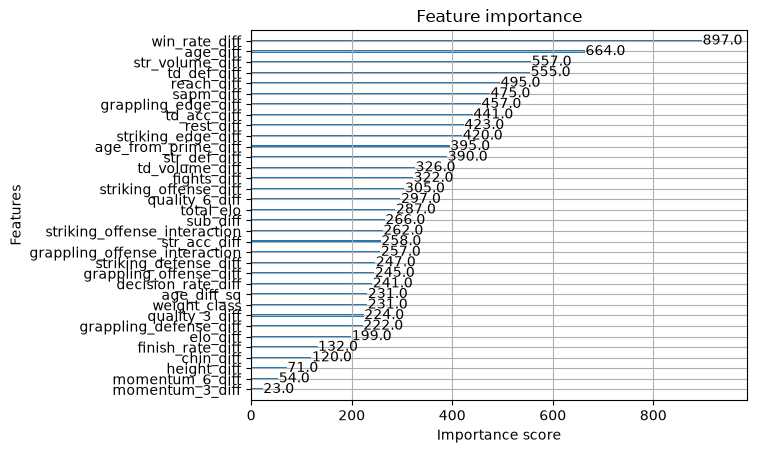

In [379]:
xgb.plot_importance(model)
plt.show()

In [380]:
importance = model.get_booster().get_score(importance_type="gain")

importance_df = pd.DataFrame({
    "feature": list(importance.keys()),
    "importance": list(importance.values())
}).sort_values("importance", ascending=False)

importance_df["importance"] /= importance_df["importance"].sum()
importance_df = importance_df.sort_values("importance", ascending=False)

print(importance_df)

                          feature  importance
22                  win_rate_diff    0.093172
30             striking_edge_diff    0.076549
6                 str_volume_diff    0.068163
31            grappling_edge_diff    0.049534
26          striking_offense_diff    0.048147
12                    td_def_diff    0.041780
8                    str_def_diff    0.032782
21                 quality_6_diff    0.032484
1                      reach_diff    0.031555
15                      rest_diff    0.029196
0                        age_diff    0.028530
19                momentum_6_diff    0.027760
27          striking_defense_diff    0.027695
9                       sapm_diff    0.027620
3                    weight_class    0.025172
14                    fights_diff    0.024528
28         grappling_offense_diff    0.023273
10                 td_volume_diff    0.022989
7                    str_acc_diff    0.022455
29         grappling_defense_diff    0.021314
20                 quality_3_diff 

In [381]:
## Shap stuff

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# global importance: mean absolute SHAP value per feature
shap_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance["pct"] = shap_importance["mean_abs_shap"] / shap_importance["mean_abs_shap"].sum() * 100
print(shap_importance.round(4))

                          feature  mean_abs_shap      pct
22                  win_rate_diff         0.4664  22.1056
6                 str_volume_diff         0.2689  12.7439
30             striking_edge_diff         0.1480   7.0159
0                        age_diff         0.1463   6.9355
31            grappling_edge_diff         0.1219   5.7751
12                    td_def_diff         0.1083   5.1330
14                    fights_diff         0.1019   4.8296
9                       sapm_diff         0.0850   4.0279
15                      rest_diff         0.0671   3.1801
21                 quality_6_diff         0.0650   3.0787
26          striking_offense_diff         0.0637   3.0206
1                      reach_diff         0.0602   2.8521
10                 td_volume_diff         0.0529   2.5088
8                    str_def_diff         0.0462   2.1880
4             age_from_prime_diff         0.0460   2.1813
27          striking_defense_diff         0.0343   1.6259
7             

In [382]:
# correlation between feature value and its own SHAP value tells you effect direction
direction = pd.DataFrame({
    "feature": X_test.columns,
    "shap_value_corr": [
        np.corrcoef(X_test[col], shap_values[:, i])[0, 1]
        for i, col in enumerate(X_test.columns)
    ]
}).sort_values("shap_value_corr", ascending=False)
print(direction.round(3))

                          feature  shap_value_corr
22                  win_rate_diff            0.991
12                    td_def_diff            0.963
31            grappling_edge_diff            0.955
30             striking_edge_diff            0.954
21                 quality_6_diff            0.944
26          striking_offense_diff            0.930
27          striking_defense_diff            0.919
28         grappling_offense_diff            0.919
6                 str_volume_diff            0.913
1                      reach_diff            0.904
8                    str_def_diff            0.897
7                    str_acc_diff            0.863
29         grappling_defense_diff            0.861
19                momentum_6_diff            0.857
25                      chin_diff            0.805
10                 td_volume_diff            0.785
14                    fights_diff            0.769
2                     height_diff            0.622
20                 quality_3_di

In [383]:
# Elo Leaderboard

# ---- Full-history Elo run (separate from the train-only fighter_elo used for model features) ----
# fighter_elo (built earlier) is frozen at CUTOFF_DATE and used for model training —
# it deliberately excludes test-period fights to avoid leakage.
# For a "current ratings" leaderboard we want every fight applied, so we recompute here.

fighter_elo_full = {}
K_LEADERBOARD = 20  # lower than model K=32 — reduces single-fight swings for display purposes

df_sorted = df.sort_values("date").reset_index(drop=True)

for _, row in df_sorted.iterrows():
    r = row["r_name"]
    b = row["b_name"]

    r_rating = fighter_elo_full.get(r, 1500)
    b_rating = fighter_elo_full.get(b, 1500)

    r_exp = expected_score(r_rating, b_rating)
    b_exp = 1 - r_exp

    r_score = 1 if row["winner_corner"] == 1 else 0
    b_score = 1 - r_score

    fighter_elo_full[r] = r_rating + K_LEADERBOARD * (r_score - r_exp)
    fighter_elo_full[b] = b_rating + K_LEADERBOARD * (b_score - b_exp)

elo_df = pd.DataFrame({
    "fighter": list(fighter_elo_full.keys()),
    "elo": list(fighter_elo_full.values())
})
elo_df["fighter"] = elo_df["fighter"].str.strip().str.lower()

# ---- Weight class assignment ----
def weight_to_division(w):
    # w in kg, standard UFC limits
    bounds = [
        (56.7, "flyweight"), (61.2, "bantamweight"), (65.8, "featherweight"),
        (70.3, "lightweight"), (77.1, "welterweight"), (83.9, "middleweight"),
        (93.0, "light heavyweight"), (120.2, "heavyweight")
    ]
    for limit, name in bounds:
        if w <= limit + 1:  # small buffer for rounding
            return name
    return "heavyweight"

fighter_weight = (
    df.sort_values("date")
    .groupby("r_name")["r_weight_x"]
    .last()
    .reset_index()
    .rename(columns={"r_name": "fighter", "r_weight_x": "weight"})
)
fighter_weight["division"] = fighter_weight["weight"].apply(weight_to_division)

# ---- Last fight date per fighter, for recency filter ----
red_last = df[["r_name", "date"]].rename(columns={"r_name": "fighter"})
blue_last = df[["b_name", "date"]].rename(columns={"b_name": "fighter"})
fighter_last_fight = (
    pd.concat([red_last, blue_last])
    .groupby("fighter")["date"]
    .max()
    .reset_index()
    .rename(columns={"date": "last_fight_date"})
)

cutoff_date = df["date"].max() - pd.DateOffset(years=2)

# ---- Build leaderboard ----
leaderboard = elo_df.merge(fighter_weight[["fighter", "division"]], on="fighter", how="left")
leaderboard = leaderboard.merge(fighter_last_fight, on="fighter", how="left")
leaderboard = leaderboard.dropna(subset=["division", "last_fight_date"])
leaderboard = leaderboard[leaderboard["last_fight_date"] >= cutoff_date]
leaderboard = leaderboard.sort_values("elo", ascending=False)

for division, group in leaderboard.groupby("division"):
    print(f"\n=== {division.upper()} ===")
    for i, row in enumerate(group.head(5).itertuples(), start=1):
        print(f"{i}. {row.fighter.title():<25} Elo: {row.elo:.1f}  (last fought {row.last_fight_date.date()})")


=== BANTAMWEIGHT ===
1. Merab Dvalishvili         Elo: 1607.7  (last fought 2025-12-06)
2. Sean O'Malley             Elo: 1595.0  (last fought 2026-06-14)
3. Song Yadong               Elo: 1590.8  (last fought 2026-08-29)
4. Mario Bautista            Elo: 1585.8  (last fought 2026-07-11)
5. Petr Yan                  Elo: 1583.5  (last fought 2025-12-06)

=== FEATHERWEIGHT ===
1. Aljamain Sterling         Elo: 1618.7  (last fought 2026-04-25)
2. Alexander Volkanovski     Elo: 1614.3  (last fought 2026-01-31)
3. Movsar Evloev             Elo: 1600.0  (last fought 2026-03-21)
4. Lerone Murphy             Elo: 1584.6  (last fought 2026-03-21)
5. Arnold Allen              Elo: 1580.5  (last fought 2026-05-16)

=== FLYWEIGHT ===
1. Valentina Shevchenko      Elo: 1620.8  (last fought 2025-11-15)
2. Alexandre Pantoja         Elo: 1589.2  (last fought 2025-12-06)
3. Joshua Van                Elo: 1584.6  (last fought 2026-05-09)
4. Natalia Silva             Elo: 1577.4  (last fought 2026-01-24

In [384]:
# ============================================================
# SAVE PRODUCTION ARTIFACTS: model, elo, and feature scalers/defaults
# ============================================================

rate_train_mask = df["date"] < CUTOFF_DATE

# Pooled (red + blue combined) train-only mean/std for each z-scored raw
# stat — a fighter's stat scale shouldn't depend on which corner they're
# in, so red/blue training values are pooled into one distribution here,
# then applied identically to whichever corner a fighter appears in at
# inference time.
scaler_source_cols = {
    "splm":      ("r_splm_x", "b_splm_y"),
    "str_acc":   ("r_str_acc_x", "b_str_acc_y"),
    "str_def":   ("r_str_def_x", "b_str_def_y"),
    "sapm":      ("r_sapm_x", "b_sapm_y"),
    "td_avg":    ("r_td_avg_x", "b_td_avg_y"),
    "td_acc":    ("r_td_avg_acc_x", "b_td_avg_acc_y"),
    "td_def":    ("r_td_def_x", "b_td_def_y"),
    "sub_avg":   ("r_sub_avg_x", "b_sub_avg_y"),
    "ko_win_q":  ("r_total_weighted_ko_win", "b_total_weighted_ko_win"),
    "sub_win_q": ("r_total_weighted_sub_win", "b_total_weighted_sub_win"),
    "ko_loss_q": ("r_total_weighted_ko_loss", "b_total_weighted_ko_loss"),
    "sub_loss_q":("r_total_weighted_sub_loss", "b_total_weighted_sub_loss"),
    "chin":      ("r_chin_metric", "b_chin_metric"),
}

feature_scalers = {}
for key, (col_r, col_b) in scaler_source_cols.items():
    pooled = pd.concat([
        df.loc[rate_train_mask, col_r],
        df.loc[rate_train_mask, col_b]
    ])
    std = pooled.std()
    feature_scalers[key] = {"mean": pooled.mean(), "std": std if std > 0 else 1.0}

# Train-only fill defaults for rate-based features (0 would be the wrong
# assumption for a debut fighter — see the chin_metric fillna fix)
feature_defaults = {}
for name, (col_r, col_b) in [
    ("chin_metric", ("r_chin_metric", "b_chin_metric")),
    ("finish_rate", ("r_finish_rate", "b_finish_rate")),
    ("decision_rate", ("r_decision_rate", "b_decision_rate")),
]:
    pooled = pd.concat([df.loc[rate_train_mask, col_r], df.loc[rate_train_mask, col_b]])
    feature_defaults[name] = pooled.mean()

feature_defaults["prime_age"] = PRIME_AGE

joblib.dump(model, "model/ufc_xgb_model.pkl")
joblib.dump({"scalers": feature_scalers, "defaults": feature_defaults}, "model/ufc_feature_scalers.pkl")

fighter_elo_prod = {}
K = 32  # match training K exactly

df_sorted = df.sort_values("date").reset_index(drop=True)

for _, row in df_sorted.iterrows():
    r, b = row["r_name"], row["b_name"]
    r_rating = fighter_elo_prod.get(r, 1500)
    b_rating = fighter_elo_prod.get(b, 1500)
    r_exp = expected_score(r_rating, b_rating)
    b_exp = 1 - r_exp
    r_score = 1 if row["winner_corner"] == 1 else 0
    b_score = 1 - r_score
    fighter_elo_prod[r] = r_rating + K * (r_score - r_exp)
    fighter_elo_prod[b] = b_rating + K * (b_score - b_exp)

joblib.dump(fighter_elo_prod, "model/ufc_fighter_elo.pkl")

['model/ufc_fighter_elo.pkl']

## SHAP Explain Fight

In [385]:
def get_fight_explanation(feature, value, shap_value, total_shap):

    importance_pct = (
        abs(shap_value) / total_shap
        if total_shap > 0 else 0
    )

    # -------------------------
    # MAGNITUDE
    # -------------------------

    if importance_pct >= 0.20:
        strength = "Major factor"
        modifier = "a major"
    elif importance_pct >= 0.10:
        strength = "Strong factor"
        modifier = "a clear"
    elif importance_pct >= 0.05:
        strength = "Moderate factor"
        modifier = "a slight"
    else:
        strength = "Minor factor"
        modifier = "a small"

    explanations = {

        "age_diff":
            f"has {modifier} age advantage for this matchup",

        "reach_diff":
            f"has {modifier} advantage in controlling distance",

        "height_diff":
            f"has {modifier} physical advantage in the matchup",

        "str_volume_diff":
            f"is likely to have {modifier} edge in striking pace and volume",

        "str_acc_diff":
            f"is more likely to land the cleaner striking",

        "str_def_diff":
            f"should be better equipped to avoid damage in striking exchanges",

        "sapm_diff":
            f"has {modifier} advantage in limiting the damage they give up",

        "td_volume_diff":
            f"has {modifier} wrestling advantage and a stronger path to controlling the fight",

        "td_acc_diff":
            f"is more likely to turn wrestling opportunities into control",

        "td_def_diff":
            f"is better equipped to prevent the opponent from forcing grappling exchanges",

        "sub_diff":
            f"has {modifier} submission threat if the fight becomes a grappling battle",

        "fights_diff":
            f"has {modifier} UFC experience advantage",

        "rest_diff":
            f"has {modifier} recent activity advantage",

        "momentum_3_diff":
            f"comes in with {modifier} recent momentum",

        "momentum_6_diff":
            f"has been more consistently successful in their recent fights",

        "quality_3_diff":
            f"has {modifier} advantage in recent performances against quality opposition",

        "quality_6_diff":
            f"has {modifier} stronger history against quality opposition",

        "win_rate_diff":
            f"has {modifier} stronger overall track record",

        "elo_diff":
            f"has {modifier} stronger overall competitive track record",
    }

    if feature not in explanations:
        return None

    return {
        "strength": strength,
        "text": explanations[feature],
        "importance": importance_pct
    }

In [386]:
def get_fight_explanation(feature, value, shap_value, predicted_is_red):
    """
    Converts model features into simple fight-relevant explanations.
    Returns None for features we don't want to explain individually.
    """

    # ---------------------------------------------------------
    # Determine whether this feature favours the predicted fighter
    # ---------------------------------------------------------

    if predicted_is_red:
        favours_predicted = shap_value > 0
    else:
        favours_predicted = shap_value < 0

    # ---------------------------------------------------------
    # Group related features together
    # ---------------------------------------------------------

    feature_groups = {

        "wrestling": [
            "td_volume_diff",
            "td_acc_diff",
            "td_def_diff",
            "sub_diff"
        ],

        "striking": [
            "str_volume_diff",
            "str_acc_diff",
            "str_def_diff",
            "sapm_diff"
        ],

        "physical": [
            "age_diff",
            "reach_diff",
            "height_diff"
        ],

        "experience": [
            "fights_diff"
        ],

        "recent_form": [
            "momentum_3_diff",
            "momentum_6_diff"
        ],

        "win_quality": [
            "quality_3_diff",
            "quality_6_diff"
        ],

        "overall_record": [
            "win_rate_diff"
        ],

        "rest": [
            "rest_diff"
        ],

        "elo": [
            "elo_diff"
        ]
    }

    # Find which group this feature belongs to
    group = None

    for group_name, group_features in feature_groups.items():
        if feature in group_features:
            group = group_name
            break

    if group is None:
        return None

    # ---------------------------------------------------------
    # Human-readable descriptions
    # ---------------------------------------------------------

    descriptions = {

        "wrestling":
            "a wrestling and grappling advantage",

        "striking":
            "an advantage in striking exchanges",

        "physical":
            "a physical advantage",

        "experience":
            "a significant experience advantage",

        "recent_form":
            "better recent form",

        "win_quality":
            "a stronger history against quality opposition",

        "overall_record":
            "a stronger overall record",

        "rest":
            "a more favourable recent activity level",

        "elo":
            "a stronger overall competitive rating"
    }

    return {
        "group": group,
        "text": descriptions[group],
        "favours_predicted": favours_predicted
    }


def explain_fight_by_index(model, df_model, df_balanced, index):

    # ---------------------------------------------------------
    # Get the actual fight
    # ---------------------------------------------------------

    fight = df_balanced.loc[index]

    red = str(fight["r_name"]).title()
    blue = str(fight["b_name"]).title()

    # ---------------------------------------------------------
    # Build model input
    # ---------------------------------------------------------

    X_fight = df_model.loc[[index], features].copy()

    # Force everything to numeric
    X_fight = X_fight.apply(pd.to_numeric, errors="coerce")

    # Match model feature order exactly
    X_fight = X_fight[model.get_booster().feature_names]

    # ---------------------------------------------------------
    # Prediction
    # ---------------------------------------------------------

    probability = model.predict_proba(X_fight)[0, 1]

    if probability >= 0.5:
        predicted = red
        predicted_is_red = True
        win_probability = probability
    else:
        predicted = blue
        predicted_is_red = False
        win_probability = 1 - probability

    # ---------------------------------------------------------
    # SHAP
    # ---------------------------------------------------------

    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_fight)

    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    shap_values = np.array(shap_values).flatten()

    explanation = pd.DataFrame({
        "feature": X_fight.columns,
        "value": X_fight.iloc[0].values,
        "shap": shap_values
    })

    explanation["abs_shap"] = explanation["shap"].abs()

    total_shap = explanation["abs_shap"].sum()

    # ---------------------------------------------------------
    # Convert SHAP into fight concepts
    # ---------------------------------------------------------

    factors = []

    for _, row in explanation.iterrows():

        result = get_fight_explanation(
            row["feature"],
            row["value"],
            row["shap"],
            predicted_is_red
        )

        if result is None:
            continue

        factors.append({
            "group": result["group"],
            "text": result["text"],
            "shap": abs(row["shap"]),
            "favours_predicted": result["favours_predicted"]
        })

    factors = pd.DataFrame(factors)

    if factors.empty:
        print("No meaningful explanation available.")
        return explanation

    # ---------------------------------------------------------
    # Combine multiple features from the same concept
    # ---------------------------------------------------------

    grouped = (
        factors
        .groupby(
            ["group", "text", "favours_predicted"],
            as_index=False
        )["shap"]
        .sum()
    )

    grouped["importance"] = grouped["shap"] / total_shap

    # ---------------------------------------------------------
    # Remove weak/noise factors
    #
    # Dynamic threshold:
    # - anything under 8% of total SHAP is ignored
    # - but if something is genuinely important it remains
    # ---------------------------------------------------------

    grouped = grouped[grouped["importance"] >= 0.08]

    # Sort strongest first
    grouped = grouped.sort_values(
        "importance",
        ascending=False
    )

    # ---------------------------------------------------------
    # Dynamic strength labels
    # ---------------------------------------------------------

    def strength_label(importance):

        if importance >= 0.30:
            return "Huge Factor"

        elif importance >= 0.18:
            return "Major Factor"

        elif importance >= 0.10:
            return "Strong Factor"

        else:
            return "Moderate Factor"

    # ---------------------------------------------------------
    # Split into advantages and concerns
    # ---------------------------------------------------------

    advantages = grouped[
        grouped["favours_predicted"] == True
    ].copy()

    concerns = grouped[
        grouped["favours_predicted"] == False
    ].copy()

    # ---------------------------------------------------------
    # Print
    # ---------------------------------------------------------

    print("=" * 60)
    print(f"{red} vs {blue}")
    print("=" * 60)

    print("\nPREDICTION")
    print(f"{predicted} — {win_probability:.1%}")

    # ---------------------------------------------------------
    # Advantages
    # ---------------------------------------------------------

    print(f"\nSTRONGEST REASONS {predicted.upper()} IS FAVOURED:")

    if advantages.empty:

        print("• No major advantages identified.")

    else:

        for _, row in advantages.iterrows():

            strength = strength_label(row["importance"])

            print(
                f"• {strength}: {row['text']}"
            )

    # ---------------------------------------------------------
    # Concerns
    # ---------------------------------------------------------

    print(f"\nSTRONGEST CONCERNS FOR {predicted.upper()}:")

    if concerns.empty:

        print("• No major concerns identified.")

    else:

        for _, row in concerns.iterrows():

            strength = strength_label(row["importance"])

            print(
                f"• {strength}: {row['text']}"
            )

    return explanation

In [387]:
def explain_fight_by_index(model, df_model, df_balanced, index):

    # =========================================================
    # GET FIGHT
    # =========================================================

    fight = df_balanced.loc[index]

    red = str(fight["r_name"]).title()
    blue = str(fight["b_name"]).title()

    # =========================================================
    # BUILD MODEL INPUT
    # =========================================================

    X_fight = df_model.loc[[index], features].copy()

    # Make absolutely sure everything is numeric
    X_fight = X_fight.apply(pd.to_numeric, errors="coerce")

    # Match the exact feature order used by XGBoost
    X_fight = X_fight[model.get_booster().feature_names]

    # =========================================================
    # PREDICTION
    # =========================================================

    probability = model.predict_proba(X_fight)[0, 1]

    if probability >= 0.5:
        predicted = red
        predicted_is_red = True
        win_probability = probability
    else:
        predicted = blue
        predicted_is_red = False
        win_probability = 1 - probability

    # =========================================================
    # SHAP
    # =========================================================

    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_fight)

    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    shap_values = np.array(shap_values).flatten()

    explanation = pd.DataFrame({
        "feature": X_fight.columns,
        "value": X_fight.iloc[0].values,
        "shap": shap_values
    })

    explanation["abs_shap"] = explanation["shap"].abs()

    total_shap = explanation["abs_shap"].sum()

    # =========================================================
    # GROUP FEATURES INTO ACTUAL FIGHT CONCEPTS
    # =========================================================

    feature_groups = {

        "wrestling": [
            "td_volume_diff",
            "td_acc_diff",
            "td_def_diff",
            "sub_diff"
        ],

        "striking": [
            "str_volume_diff",
            "str_acc_diff",
            "str_def_diff",
            "sapm_diff"
        ],

        "physical": [
            "age_diff",
            "reach_diff",
            "height_diff"
        ],

        "experience": [
            "fights_diff"
        ],

        "recent_form": [
            "momentum_3_diff",
            "momentum_6_diff"
        ],

        "win_quality": [
            "quality_3_diff",
            "quality_6_diff"
        ],

        "overall_record": [
            "win_rate_diff"
        ],

        "rest": [
            "rest_diff"
        ],

        "elo": [
            "elo_diff"
        ]
    }

    # Human-readable names
    group_names = {

        "wrestling":
            "wrestling and grappling advantage",

        "striking":
            "striking advantage",

        "physical":
            "physical advantage",

        "experience":
            "experience advantage",

        "recent_form":
            "better recent form",

        "win_quality":
            "stronger opposition history",

        "overall_record":
            "stronger overall record",

        "rest":
            "more favourable activity level",

        "elo":
            "stronger overall competitive level"
    }

    # =========================================================
    # CALCULATE GROUP IMPORTANCE
    # =========================================================

    factors = []

    for group, group_features in feature_groups.items():

        group_rows = explanation[
            explanation["feature"].isin(group_features)
        ]

        if group_rows.empty:
            continue

        # Combine all SHAP contributions in this category
        group_shap = group_rows["shap"].sum()

        # Magnitude of influence
        group_importance = group_rows["abs_shap"].sum()

        # Determine whether this category favours
        # the predicted fighter
        #
        # Red prediction:
        # positive SHAP = Red
        #
        # Blue prediction:
        # negative SHAP = Blue

        if predicted_is_red:
            favours_predicted = group_shap > 0
        else:
            favours_predicted = group_shap < 0

        factors.append({
            "group": group,
            "name": group_names[group],
            "shap": group_importance,
            "direction": favours_predicted
        })

    factors = pd.DataFrame(factors)

    # =========================================================
    # CALCULATE RELATIVE IMPORTANCE
    # =========================================================

    if not factors.empty:

        factors["importance"] = (
            factors["shap"] / total_shap
        )

    # =========================================================
    # REMOVE VERY SMALL / IRRELEVANT FACTORS
    # =========================================================

    # Anything contributing less than 8% of the total
    # explanation is considered too small to mention.

    factors = factors[
        factors["importance"] >= 0.08
    ]

    # =========================================================
    # SPLIT ADVANTAGES / CONCERNS
    # =========================================================

    advantages = factors[
        factors["direction"] == True
    ].sort_values(
        "importance",
        ascending=False
    )

    concerns = factors[
        factors["direction"] == False
    ].sort_values(
        "importance",
        ascending=False
    )

    # =========================================================
    # MAGNITUDE LABEL
    # =========================================================

    def magnitude(importance):

        if importance >= 0.30:
            return "Huge Factor"

        elif importance >= 0.20:
            return "Major Factor"

        elif importance >= 0.12:
            return "Strong Factor"

        else:
            return "Moderate Factor"

    # =========================================================
    # OUTPUT
    # =========================================================

    print("=" * 60)
    print(f"{red} vs {blue}")
    print("=" * 60)

    print("\nPREDICTION")
    print(f"{predicted} — {win_probability:.1%}")

    # ---------------------------------------------------------
    # ADVANTAGES
    # ---------------------------------------------------------

    print(
        f"\nSTRONGEST REASONS "
        f"{predicted.upper()} IS FAVOURED:"
    )

    if advantages.empty:

        print("• No major advantages identified.")

    else:

        for _, row in advantages.iterrows():

            print(
                f"• {magnitude(row['importance'])}: "
                f"{row['name']}"
            )

    # ---------------------------------------------------------
    # CONCERNS
    # ---------------------------------------------------------

# ---------------------------------------------------------
# CONCERNS
# ---------------------------------------------------------

    print(
        f"\nSTRONGEST CONCERNS "
        f"FOR {predicted.upper()}:"
    )

    if concerns.empty:

        print("• No major concerns identified.")

    else:

        for _, row in concerns.iterrows():

            print(
                f"• {magnitude(row['importance'])}: "
                f"opponent's {row['name']}"
            )

    return explanation

In [388]:
i = 15144

explanation = explain_fight_by_index(
    model,
    df_model,
    df_balanced,
    i
)

print("\n" + "="*50 + "\n")
print(df_balanced.iloc[i][['method_x', 'winner']])

Edgar Chairez vs Cj Vergara

PREDICTION
Edgar Chairez — 55.6%

STRONGEST REASONS EDGAR CHAIREZ IS FAVOURED:
• Strong Factor: wrestling and grappling advantage
• Moderate Factor: experience advantage

STRONGEST CONCERNS FOR EDGAR CHAIREZ:
• Major Factor: opponent's striking advantage
• Moderate Factor: opponent's physical advantage


method_x       Submission
winner      Edgar Chairez
Name: 15144, dtype: object
